# K-Means Clustering -> PCR -> Logistic Regression

## Importing the libraries

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [50]:
dataset = pd.read_csv("Wine.csv")

In [51]:
# Same thing
# X = dataset.iloc[ : , 3:].values
wine_properties = dataset.iloc[ : , :].values # For discontinuous column

## Using the elbow method to find out the optimal number of clusters

In [52]:
from sklearn.cluster import KMeans

init="k-means++" is used to choose better starting centroids, so K-Means works faster and gives more stable, better clusters.

In [53]:
WCSS = []
for i in range(1,11):
  kmeans = KMeans(n_clusters= i , init = "k-means++", random_state = 42)
  kmeans.fit(wine_properties)
  WCSS.append(kmeans.inertia_)

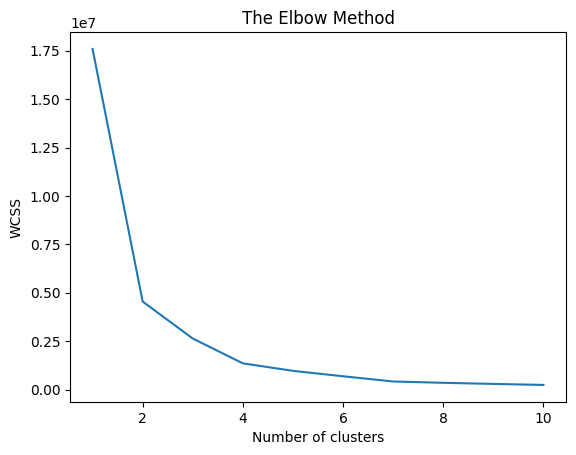

In [54]:
# plt.plot(x,y)
plt.plot(range(1, 11), WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K_Means model on the datset

In [55]:
kmeans = KMeans(n_clusters=4, init = "k-means++", random_state= 42)
y_kmeans = kmeans.fit_predict(wine_properties)

In [56]:
print(y_kmeans)

[1 1 1 2 3 2 2 2 1 1 2 2 2 1 2 2 2 1 2 3 3 3 1 1 3 3 1 2 1 1 2 2 1 2 1 1 3
 1 1 3 3 1 1 3 3 1 1 1 1 2 1 2 1 2 1 1 1 2 2 0 3 0 3 0 0 3 0 0 3 3 3 0 0 1
 3 0 0 0 3 0 0 3 3 0 0 0 0 0 3 3 0 0 0 0 0 1 3 0 3 0 3 0 0 0 3 0 0 0 0 3 0
 0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 3 0 0 3 3 3 3 0 0 3 3 3 0 0 3 3 0 3
 3 0 0 0 0 3 3 3 0 3 3 3 0 3 0 3 3 0 3 3 3 3 0 0 3 3 3 3 3 0]


Dimension Reduction process


## Adding the predictied column to the dataset

In [57]:
result = y_kmeans.reshape(len(y_kmeans), 1)

In [58]:
np.set_printoptions(suppress = True)
final_dataset =  np.concatenate((wine_properties, result), axis = 1)

In [59]:
#np.savetxt("final_dataset.csv", final_dataset, delimiter = ",")

## Importing the dataset

In [60]:
ds = pd.read_csv("Wine_3_Clusters.csv")
X = ds.iloc[:, : -1].values
y = ds.iloc[:, -1].values

## Spliting the dataset into the Training and Test set

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature Scaling


In [62]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Applying PCA

In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## The Training Set

In [64]:
np.set_printoptions(suppress=True)
training_set = np.concatenate((X_train, y_train.reshape(len(y_train),1)),1)
print(training_set)

[[-2.17884511  1.07218467  3.        ]
 [-1.80819239 -1.57822344  2.        ]
 [ 1.09829474 -2.22124345  2.        ]
 [-2.55584748  1.66210369  3.        ]
 [ 1.85698063 -0.24157317  1.        ]
 [ 2.58288576  1.3766817   1.        ]
 [ 0.87287612 -2.25618512  2.        ]
 [-0.41838403 -2.35415681  2.        ]
 [-0.30497725 -2.27659433  2.        ]
 [ 2.14082532  1.10052871  1.        ]
 [-2.98136465  0.24715918  3.        ]
 [ 1.96188242 -1.25407738  2.        ]
 [-2.16177795  0.97596655  3.        ]
 [ 2.21976084  2.39507167  1.        ]
 [-2.30179529  0.20579196  3.        ]
 [-3.00953827  0.27914121  3.        ]
 [ 2.63443473  0.86831312  1.        ]
 [-1.09219965  3.53906625  3.        ]
 [ 2.62578435  0.00296853  1.        ]
 [ 0.19807734 -2.29193443  2.        ]
 [-2.67442753  2.58800132  3.        ]
 [-2.54763698  0.45270389  3.        ]
 [ 1.77416736 -0.84358694  2.        ]
 [-2.77786938  0.43209026  3.        ]
 [-2.86679938  1.87580875  3.        ]
 [ 1.35498845 -0.03995452

## Training the Logistic Regression model on the Training set

In [65]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

We are doing logistic regression because, to predict new wine and which segment will it goes..
also need to do the pca for new one.. and the structure is ready.


## Predicting the Test set Result

In [67]:
y_pred = classifier.predict(X_test)
test_set = np.concatenate((X_test, y_test.reshape(len(y_test),1), y_pred.reshape(len(y_pred),1)),1)
print(test_set)

[[ 2.20685211  1.02850086  1.          1.        ]
 [-2.53651962  1.83644227  3.          3.        ]
 [ 2.19183305 -1.81240519  2.          2.        ]
 [ 2.51489251  1.38907803  1.          1.        ]
 [-0.34799131 -0.52539791  2.          2.        ]
 [ 1.44174066  0.28967451  2.          1.        ]
 [ 2.11892046  1.62960181  1.          1.        ]
 [-3.06045961  0.67095063  3.          3.        ]
 [-0.23543688 -2.16810201  2.          2.        ]
 [-1.21230749 -2.12204944  2.          2.        ]
 [-2.2070672   0.26145726  3.          3.        ]
 [-4.1975958   0.53650554  3.          3.        ]
 [ 3.11063501  2.26380692  1.          1.        ]
 [ 2.39878282 -1.29482006  2.          2.        ]
 [-2.16102953  1.9532762   3.          3.        ]
 [ 0.92662723 -3.35678339  2.          2.        ]
 [ 1.96950425  1.65130081  1.          1.        ]
 [ 3.61413167  2.68087967  1.          1.        ]
 [-1.71986182 -0.92993696  2.          2.        ]
 [ 2.93212799  0.87932076  1.  

## Making a confusion Matrix

In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]


0.9722222222222222

## Visualization of the test set

Logistic regression prediction region


/tmp/ipython-input-3946207957.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


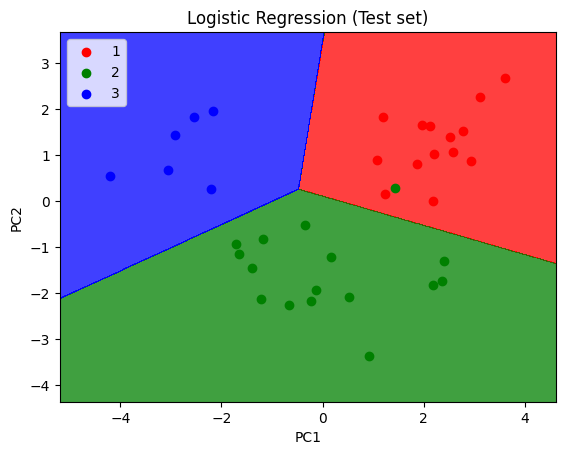

In [68]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()